# Time Series Analysis

Signification des émoticones :
- 🌞 : documentations importantes
- 👀 : documentations intéressantes à connaître
- 🌚 : en complément
- (vide) : à vous de voir

What is a time serie ? Simply put, it's a dataset where each value is measured at a known given time. Whether it's stock prices, temperature measurements, sales figures, or any other sequential data, time series data holds a rich tapestry of information about how phenomena evolve over time. Typically with time series, we want to estimate the evolution of a phenomenom with time i.e. make predictions for the future. Thus, the temporal order of the dataset is of paramount significance!

Unlike cross-sectional data, where observations are independent of each other, the temporal arrangement in time series carries inherent dependencies. Patterns, trends, and seasonal variations often emerge, providing invaluable insights into the behavior of the underlying process.

In this notebook, we will manipulate a simple time series dataset with Pandas to explore the following concepts:
- Resample and interpolate
- Patterns (Trend, Seasonality, Noise) and Additive / Multiplicative decomposition

**Objectives**
- Get to know the theory behind time series
- Analyse time series datasets with Pandas
- Discover main time series analysis challenges

**Resources**

- 🌞 https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html
- 👀 https://jakevdp.github.io/PythonDataScienceHandbook/03.11-working-with-time-series.html

**Required librairies**
- [ ] numpy
- [ ] pandas
- [ ] matplotlib
- [ ] seaborn
- [ ] pmdarima

In [8]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima as pm
import datetime

# 1. Manipulate time series with Pandas

### 1.1 Load & visualize the Air Passengers dataset ✈️ 💺

Learn how to manipulate a Pandas series.

**Resources**
- 🌞 https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html
- 👀 https://jakevdp.github.io/PythonDataScienceHandbook/03.11-working-with-time-series.html

**TODO**
- Load and visualize the dataset
- What can you tell about the overall trend of the data ?
- Select and plot a specific year (e.g. 1952) from the data using the `.index.year` attribute

In [6]:
from pmdarima.datasets import load_airpassengers

# Load dataset
START_DATE = '1949-01-01'
airline = load_airpassengers(as_series=True)

# There's no DateTimeIndex from the bundled dataset. So let's add one.
airline.index = pd.date_range(START_DATE, periods=len(airline), freq='MS')

# Write definitions to visualize, describe and eventually clean data


### 1.2 Change the sampling (D/M/Y)

Different months have different numbers of days. Calculating the number of passengers per day might help remove this uninteresting variation from the series!

**TODO**
- Create a new time serie representing the daily number of passengers using the `.index.days_in_month` attribute
- Visualize the old and new serie: do you observe any difference ?

[Text(0.5, 0, 'Month'), Text(0, 0.5, 'Passengers per day (thousands)')]

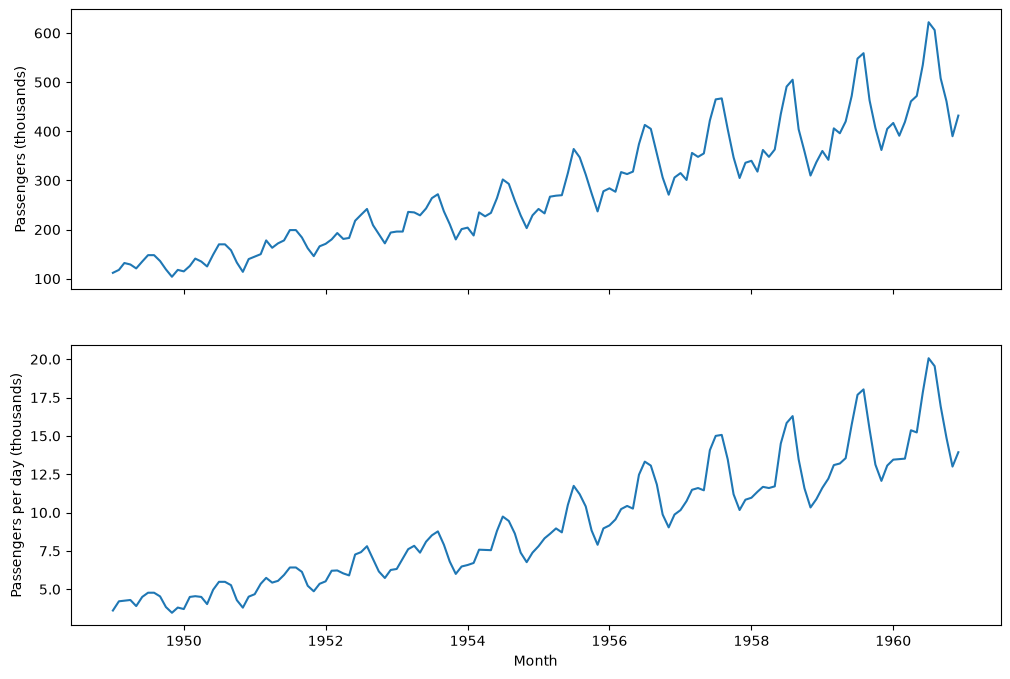

In [11]:
# Calculate the number of airline passengers per day instead of months

airline_adj = airline / airline.index.days_in_month
# Plot the unadjusted and adjusted series
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

axes[0].plot(airline)
axes[0].set(ylabel='Passengers (thousands)')

axes[1].plot(airline_adj)
axes[1].set(xlabel='Month', ylabel='Passengers per day (thousands)')

### 1.3 Interpolation

Interpolation is useful when there are missing values which we don't want to discard completely. As such, it can be used instead of the now well-known `dropna()` method.

Another use case for interpolation is when resampling a time series. The airline passengers data is given with 1 month intervals. What if we want to know (and predict) the airline frequentation at smaller intervals ? For this we can use the `resample()` and `interpolate` methods!

**Resources**
- 🌞 https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html
- 🌞 https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.interpolate.html <br/>

**TODO**
- Select a single year from the dataset and resample it to daily time
- Call `resample()` to resample the series to daily intervals
- Call `interpolate()` and play with the different methods
- Plot the results to show the differences  

/tmp/ipykernel_16034/2257053629.py:13: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  airline_linear.plot(ax=ax, label='Interpolation linéaire')
/tmp/ipykernel_16034/2257053629.py:13: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  airline_linear.plot(ax=ax, label='Interpolation linéaire')


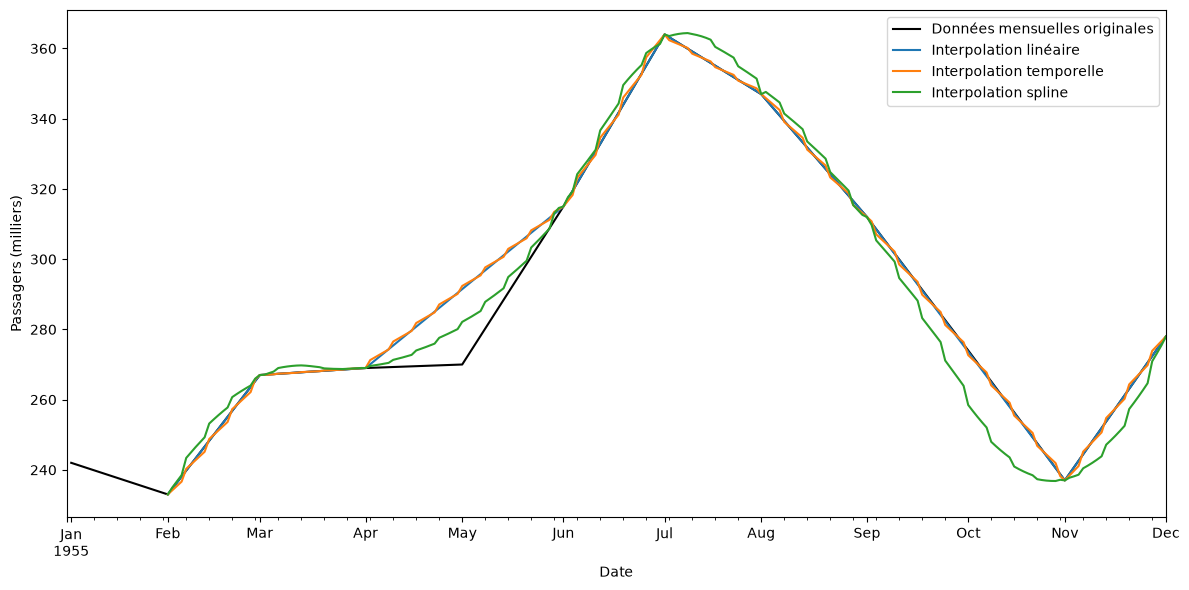

In [26]:
# Your code here
airline_1955 = airline[airline.index.year == 1955]

airline_daily = airline_1955.resample('B').asfreq()

airline_linear = airline_daily.interpolate(method='linear')
airline_time = airline_daily.interpolate(method='time')
airline_spline = airline_daily.interpolate(method='spline', order=2)

fig, ax = plt.subplots(figsize=(12, 6))

airline_1955.plot(ax=ax, style='o', label='Données mensuelles originales', color='black', markersize=8)
airline_linear.plot(ax=ax, label='Interpolation linéaire')
airline_time.plot(ax=ax, label='Interpolation temporelle')
airline_spline.plot(ax=ax, label='Interpolation spline')

ax.set_ylabel('Passagers (milliers)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

# 2. Identifying patterns: Trend & Seasonality

**Theory**

To analyze, and eventually forecast, a time series, it is useful to break it down into simple components. Typically, a time series is modeled as the contribution of three components:
- The Trend $T$: long-term movement or direction of the time series, related to the underlying growth or decline such as in upward, downward or flat trend
- The Seasonality $S$: repeating patterns or fluctuations that occur in a time series at regular intervals, such as daily, weekly, monthly, or yearly patterns
- The Residuals $R$: residual random variations or noise that cannot be explained by the trend and seasonality

Decomposing the signal into these components is useful for
- Removing noise arising from measurement errors or random fluctuations
- Isolate trend and seasonality to model and analyze them separately
- Make better forecasts

There are two main types of seasonal decomposition: the **additive** and **multiplicative** decomposition.
The additive model tries to find the best possible components $T_t$, $S_t$, $R_t$ such that at all times $t$ the serie $Y_t$ is decomposed as
$$ Y_t = T_t + S_t + R_t$$

The additive model is linear since the variations of the trend and seasonality are independent of each other. When the seasonal (periodic) variations in the time serie seem to be independent of the trend, additive models are preferred. 

Conversely, the multiplicative model tries to find the best possible components $T_t$, $S_t$, $R_t$ such that at all times $t$ the serie $Y_t$ is decomposed as
$$ Y_t = T_t * S_t * R_t$$
Note that the multiplicative model can be seen as an additive model in log-space, i.e. it is completely equivalent to
$$ \log Y_t = \log T_t + \log S_t + \log R_t$$
Multiplicative models are non linear since the variations in the trend imply variations in seasonality, and vice-versa. When the seasonal variations in the time series seems to change with time, multiplicative models are preferred.

--------------------

**Resources**

- 🌚 https://medium.com/analytics-vidhya/time-series-decomposition-part-i-trend-cycle-computation-29fac227896a
- 🌚 https://otexts.com/fpp2/components.html
- 🌞 https://machinelearningmastery.com/decompose-time-series-data-trend-seasonality/
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html<br/>
- 🌚 https://towardsdatascience.com/time-series-analysis-resampling-shifting-and-rolling-f5664ddef77e

--------------------

**TODO**
- Use the function `seasonal_decompose()` from Statmodels to decompose the dataset into its components with both an additive and multiplicative model.
- Visualize the results. Which model works best ? *(Hint: Do the residuals resemble random noise?)*

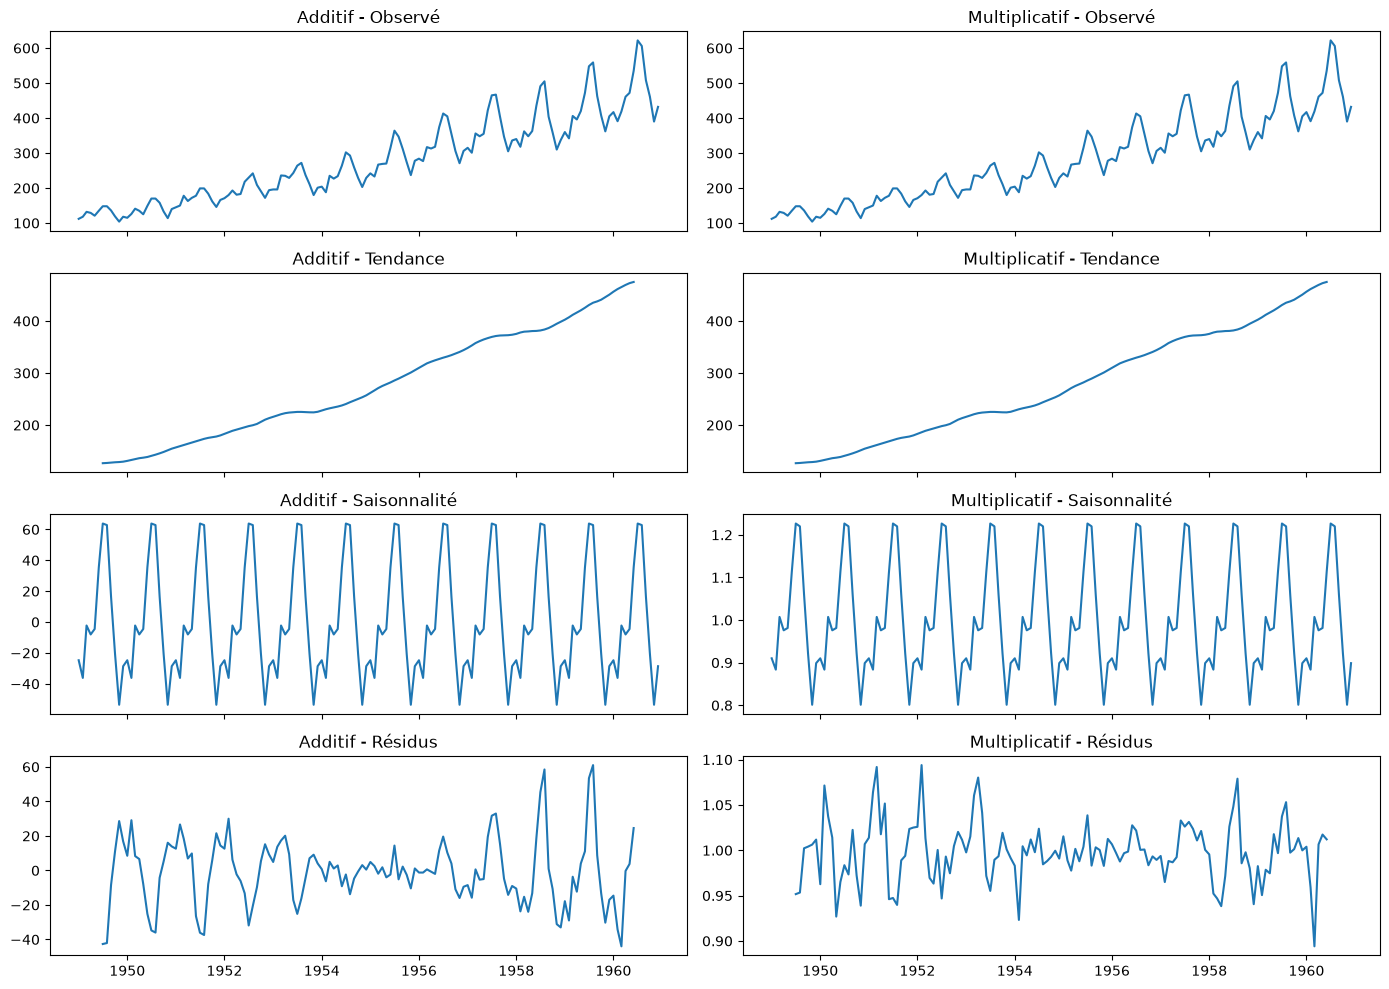

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Your code here

decomposition_add = seasonal_decompose(airline, model='additive', period=12)

# Décomposition multiplicative
decomposition_mult = seasonal_decompose(airline, model='multiplicative', period=12)

# Visualiser les deux décompositions côte à côte
fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)

# Modèle additif
axes[0, 0].plot(decomposition_add.observed)
axes[0, 0].set_title('Additif - Observé')
axes[1, 0].plot(decomposition_add.trend)
axes[1, 0].set_title('Additif - Tendance')
axes[2, 0].plot(decomposition_add.seasonal)
axes[2, 0].set_title('Additif - Saisonnalité')
axes[3, 0].plot(decomposition_add.resid)
axes[3, 0].set_title('Additif - Résidus')

# Modèle multiplicatif
axes[0, 1].plot(decomposition_mult.observed)
axes[0, 1].set_title('Multiplicatif - Observé')
axes[1, 1].plot(decomposition_mult.trend)
axes[1, 1].set_title('Multiplicatif - Tendance')
axes[2, 1].plot(decomposition_mult.seasonal)
axes[2, 1].set_title('Multiplicatif - Saisonnalité')
axes[3, 1].plot(decomposition_mult.resid)
axes[3, 1].set_title('Multiplicatif - Résidus')

plt.tight_layout()
plt.show()